#  Statistical & Probability Analysis

This notebook builds on exploratory analysis by applying statistical methods to better understand rainfall behavior.

Aim:
- Identify the underlying distribution of rainfall
- Quantify uncertainty
- Estimate probabilities of extreme events

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/cleaned_rainfall.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


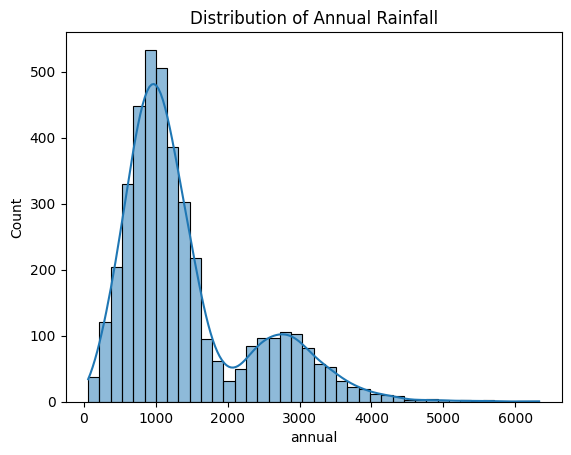

In [ ]:
sns.histplot(df['annual'], bins=40, kde=True)
plt.title("Distribution of Annual Rainfall")
plt.show()

In [ ]:
stat, p = stats.shapiro(df['annual'].sample(500))  # sample for speed
print("p-value:", p)

p-value: 3.4357346255736846e-20


In [ ]:
mu, sigma = stats.norm.fit(df['annual'])

In [ ]:
shape, loc, scale = stats.gamma.fit(df['annual'])

### Distribution Fitting

Rainfall data is tested against different statistical distributions.

The Gamma distribution is evaluated, as it is commonly used to model precipitation data.

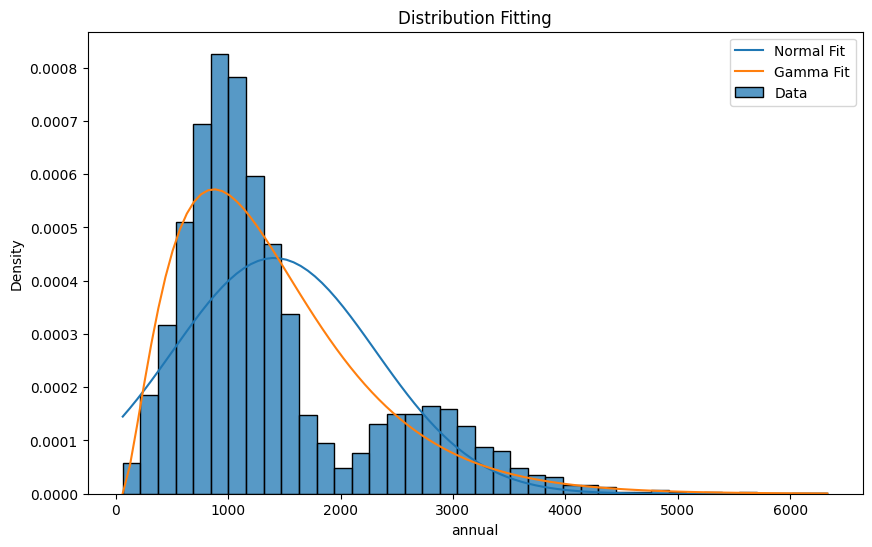

In [ ]:
x = np.linspace(df['annual'].min(), df['annual'].max(), 100)

plt.figure(figsize=(10,6))
sns.histplot(df['annual'], bins=40, stat='density', label='Data')

plt.plot(x, stats.norm.pdf(x, mu, sigma), label='Normal Fit')
plt.plot(x, stats.gamma.pdf(x, shape, loc, scale), label='Gamma Fit')

plt.legend()
plt.title("Distribution Fitting")
plt.show()

In [ ]:
mean_rain = df['annual'].mean()
var_rain = df['annual'].var()
std_rain = df['annual'].std()

print(mean_rain, var_rain, std_rain)

1409.178862973761 812303.867864173 901.2790177654049


### Probability of Extreme Events

We estimate the likelihood of extreme rainfall events using both empirical data and fitted distributions.

This helps quantify climate risk in probabilistic terms.

In [ ]:
prob_extreme = np.mean(df['annual'] > 2000)
print("Probability of extreme rainfall:", prob_extreme)

Probability of extreme rainfall: 0.20942662779397472


In [ ]:
1 - stats.gamma.cdf(2000, shape, loc, scale)

np.float64(0.2066719269754803)

In [ ]:
df['z_score'] = (df['annual'] - mean_rain) / std_rain

In [ ]:
extreme = df[np.abs(df['z_score']) > 2]
extreme.head()

,region,year,jan,feb,mar,apr,may,jun,jul,aug,...,jan-feb,mar-may,jun-sep,oct-dec,winter,summer,monsoon,post_monsoon,annual_calc,z_score
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,...,136.3,560.3,1696.3,980.3,136.3,560.3,1696.3,980.3,3373.2,2.179149
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,...,159.8,458.3,2185.9,716.7,159.8,458.3,2185.9,716.7,3520.7,2.342805
6,ANDAMAN & NICOBAR ISLANDS,1907,110.7,0.0,113.3,21.6,616.3,305.2,443.9,377.6,...,110.7,751.2,1327.1,1158.9,110.7,751.2,1327.1,1158.9,3347.9,2.151078
7,ANDAMAN & NICOBAR ISLANDS,1908,20.9,85.1,0.0,29.0,562.0,693.6,481.4,699.9,...,106.0,591.0,2303.7,575.7,106.0,591.0,2303.7,575.7,3576.4,2.404606
16,ANDAMAN & NICOBAR ISLANDS,1918,77.4,6.9,11.4,10.7,729.3,710.8,200.9,455.4,...,84.3,751.4,1670.4,768.9,84.3,751.4,1670.4,768.9,3275.0,2.070193


In [ ]:
risk = df.groupby('region')['annual'].std().sort_values(ascending=False)
risk.head()

,annual
region,
ARUNACHAL PRADESH,1183.490399
ANDAMAN & NICOBAR ISLANDS,573.301222
COASTAL KARNATAKA,525.726583
KONKAN & GOA,485.095477
NAGA MANI MIZO TRIPURA,431.734909


In [ ]:
threshold = df['annual'].quantile(0.9)
prob = np.mean(df['annual'] > threshold)

return_period = 1 / prob
print(return_period)

9.990291262135921


### Key Findings

- Rainfall distribution is positively skewed
- Normal distribution is not an ideal fit
- Gamma distribution better captures rainfall behavior
- Extreme events, while rare, are statistically significant
